1. Create a simple neural network using Keras to classify handwritten digits from the MNIST dataset, then experiment by changing the number of layers and neurons in your model to see how accuracy changes.<br><br><em><strong>Hint:</strong> Start with one hidden layer, then try adding another, and vary the number of neurons (e.g., 32, 64, 128).</em>


In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Test Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9056 - loss: 0.3353 - val_accuracy: 0.9491 - val_loss: 0.1839
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9546 - loss: 0.1563 - val_accuracy: 0.9634 - val_loss: 0.1327
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9677 - loss: 0.1114 - val_accuracy: 0.9665 - val_loss: 0.1154
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9740 - loss: 0.0871 - val_accuracy: 0.9651 - val_loss: 0.1162
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9787 - loss: 0.0719 - val_accuracy: 0.9685 - val_loss: 0.1019
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9817 - loss: 0.0602 - val_accuracy: 0.9700 - val_loss: 0.0937
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0496 - val_accuracy: 0.9692 - val_loss: 0.1027
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9873 - loss: 0.0436 - 

2. Train your MNIST model using different batch sizes (e.g., 16, 32, 64) and epochs (e.g., 5, 10, 20), and record how the training time and validation accuracy change for each combination.

In [5]:
batch_sizes = [16, 32, 64]
epochs_list = [5, 10, 20]

for batch in batch_sizes:
    for epoch in epochs_list:
        print(f"\nBatch Size = {batch}, Epochs = {epoch}")

        model.fit(
            X_train,
            y_train,
            epochs=epoch,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )


Batch Size = 16, Epochs = 5

Batch Size = 16, Epochs = 10

Batch Size = 16, Epochs = 20

Batch Size = 32, Epochs = 5

Batch Size = 32, Epochs = 10

Batch Size = 32, Epochs = 20

Batch Size = 64, Epochs = 5

Batch Size = 64, Epochs = 10

Batch Size = 64, Epochs = 20


3. Modify your Keras model to use three different optimizers (SGD, Adam, RMSprop) and compare the results by plotting training and validation loss for each optimizer.

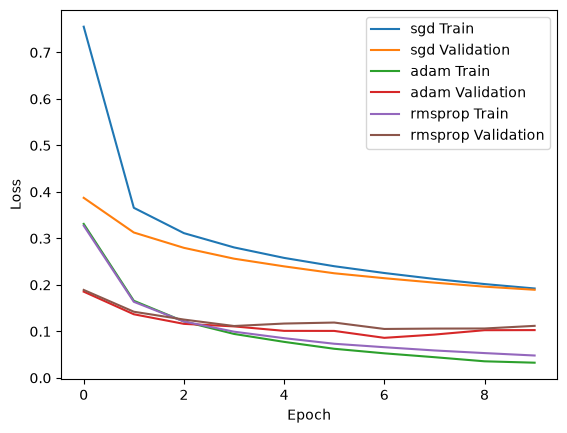

In [3]:
import matplotlib.pyplot as plt

optimizers = ['sgd', 'adam', 'rmsprop']

for opt in optimizers:

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        verbose=0
    )

    plt.plot(history.history['loss'], label=f'{opt} Train')
    plt.plot(history.history['val_loss'], label=f'{opt} Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

4. Use KerasTuner to automatically search for the best number of neurons in the first hidden layer for your MNIST classifier. Show the code you used and report the best configuration found.<br><br><em><strong>Hint:</strong> Use Hyperband or RandomSearch from keras_tuner and set a reasonable search space for neurons (e.g., 32 to 256).</em>

In [4]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def build_model(hp):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    model.add(Dense(
        units=hp.Int(
            'neurons',
            min_value=32,
            max_value=256,
            step=32
        ),
        activation='relu'
    ))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='my_tuner',
    project_name='mnist'
)

tuner.search(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Neurons:", best_hp.get('neurons'))

ModuleNotFoundError: No module named 'keras_tuner'

5. Experiment with different weight initialization methods (e.g., 'he_normal', 'glorot_uniform', 'random_normal') in your Keras model and compare their impact on the model's training speed and accuracy.

In [ ]:
initializers = [
    'he_normal',
    'glorot_uniform',
    'random_normal'
]

for init in initializers:

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(
            64,
            activation='relu',
            kernel_initializer=init
        ),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(init, "Accuracy:", acc)